### Advection Problem — Temperature

- Simulates temperature advection over a 2‑D $x$–$z$ column, marching in $x$ and solving an implicit vertical problem at each $\Delta x$.
- Uses a tridiagonal Thomas solve with central differences in $z$ at every $x$‑station for robustness.

- Governing balance:
  $$
  U(z)\,\frac{\partial T}{\partial x} \;=\; \frac{\partial}{\partial z}\!\Big(K(z)\,\frac{\partial T}{\partial z}\Big).
  $$
- Closures employed:
  - Neutral mean wind (log law): $U(z) = \dfrac{u_*}{k}\,\ln\!\big(z/z_0\big)$ with $k=0.4$.
  - Eddy diffusivity (first‑order closure): $K(z) = k\,u_*\,z$.
- Implicit marched form solved per step $\Delta x$:
  $$
  \frac{T(x+\Delta x,z)-T(x,z)}{\Delta x}
  \;=\;
  \frac{K(z)}{U(z)}\,\frac{\partial^2 T}{\partial z^2}
  \;+\;
  \frac{\partial_z K(z)}{U(z)}\,\frac{\partial T}{\partial z}.
  $$
  In code, arrays $A=K(z)$, $B=1/U(z)$, and $C=\partial_z K$ generate the tridiagonal coefficients.

Boundary and upstream conditions
- Vertical boundaries: $T(z=0)=T_s$, $T(z=H)=T_a$ (enforced by replacing the first/last rows of the system).
- Upstream column (neutral surface layer):
  $$
  w'T' \;=\; -\,\frac{(T_a - T_s)\,k\,u_*}{\ln(z_{\max}/z_0)}, 
  \qquad
  T_{\mathrm{up}}(z) \;=\; T_s \;-\; \frac{w'T'}{k\,u_*}\,\ln\!\Big(\frac{z}{z_0}\Big).
  $$
- Diagnostic flux reported:
  $$
  w'T'(z) \;=\; -\,K(z)\,\frac{\partial T}{\partial z}.
  $$



In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import math
import numpy as np
sys.path.append("../src")
for mod in ["sutton_functions"]:
    if mod in sys.modules:
            del sys.modules[mod]
            
from sutton import *

In [2]:
temperature_C = 20 # Temperature in Celsius
temperature_K = temperature_C + 273.15  # Convert to Kelvin

es = saturation_vapor_pressure(temperature_K)
rho = vapor_concentration(es, temperature_K)

print(f"Saturation vapor pressure at {temperature_C}°C is {es:.2f} Pa")
print(f"Water vapor concentration at {temperature_C}°C is {rho:.2f} g/m³")


Saturation vapor pressure at 20°C is 2366.09 Pa
Water vapor concentration at 20°C is 17.49 g/m³


### Boundary conditions

In [3]:
def no_central_difference(s, z):
    """
    Central differences; forward/backward at edges.
    """
    m = len(z)
    dz = np.ones(m)
    ds = np.ones(m)
    dz[:-1] = np.log(z[1:] / z[:-1])
    
    ds[:-1] = (s[1:] - s[:-1])    
    ds_dz = ds/dz
    ds_dz[-1] = ds_dz[-2]
    
    return ds_dz


# Water vapor script
k = 0.4  # von Karman constant
g = 9.8 

# Flow conditions
ustar = 0.2      # Friction velocity (m/s)
zom = 0.5/100    # Momentum roughness length (m)
zoh =  zom*7.4*np.exp(-2.4*(ustar*zom/1.5e-5)**0.25)
# R = ustar*zom/1.5e-5

# Domain specification
Lx = 2000
Hmax = 50

Lx=100000 
Hmax=50

xmin = 0
xmax = Lx
zmin = zom
zmax = Hmax

# Generate grid
nx = 5000
nz = 200
dx = (xmax - xmin) / nx
dz = (zmax - zmin) / nz

z = np.arange(zmin, zmax, dz)
x = np.arange(xmin, xmax + dx, dx)

# Generate the mean velocity from log-law
U = (ustar / k) * np.log(z / zom)

# Specify upwind temperature (as background), used to specify
# downwind surfce humidity
Ta_u = 25
Ts_u = 30
wT = - (Ta_u - Ts_u)*k*ustar/np.log(zmax/zom)
Tup = Ts_u - wT/(k*ustar)*np.log(z/zom)
Ts_d = 20
Ta_d = Ta_u

wT_down = - (Ta_d - Ts_d)*k*ustar/np.log(zmax/zom)
Tdown = Ts_d - wT_down/(k*ustar)*np.log(z/zom)

es = saturation_vapor_pressure(Ts_u + 273.15)
rho = vapor_concentration(es, Ts_u + 273.15)

# Water vapor boundary conditions (gm/m3)
Qs = rho      # Surface wv concentration
Qa = 25       # Upwind background atmospheric wv concentration
Qs_u = Qa
print("Water vapor boundary conditions = {0:.2f} (gm/m3) ".format( Qs))

Water vapor boundary conditions = 31.12 (gm/m3) 


## Solve water vapor

In [4]:
# Specify upwind wv concentration (as background)
Qup = np.ones(nz) * Qa

# Setup coefficients for implicit scheme
A = k * z * ustar
B = 1.0 / (U+ 1e-10)
C = our_central_difference(A, dz)

# Upwind wv concentrations and fluxes
Q1 = Qup
Q = np.zeros((nx + 1, nz))
Q[0, :] = Q1
FluxQ = np.zeros((nx + 1, nz))

dQdz = no_central_difference(Q1, z)
FluxQ[0, :] = - A/z * dQdz

# Begin downwind calculations by marching along x
for i in range(nx):
    Q2, Fq = integrate_H2O_implicit(nx, nz, dx, dz, A, B, C, Q1, Qs, Qa, z)
    Q[i+1, :] = Q2
    FluxQ[i+1, :] = Fq
    Q1 = Q2

FluxQ[FluxQ < 1e-10] = 0    

### Temperature

In [5]:
# Setup coefficients for implicit scheme
A = k * z * ustar
B = 1.0 / (U + 1e-10)
C = our_central_difference(A, dz)

# Upwind wv concentrations and fluxes
T1 = Tup
T = np.zeros((nx + 1, nz))
T[0, :] = T1
FluxT = np.zeros((nx + 1, nz))
dTdz = no_central_difference(T1, z)

FluxT[0, :]  = - A/z * dTdz 

# Begin downwind calculations by marching along x
for i in range(nx):
    T2, FT = integrate_T_implicit(nx, nz, dx, dz, A, B, C, T1, Ts_d, Ta_d, z)
    T[i + 1, :] = T2
    FluxT[i + 1, :] = FT
    T1 = T2

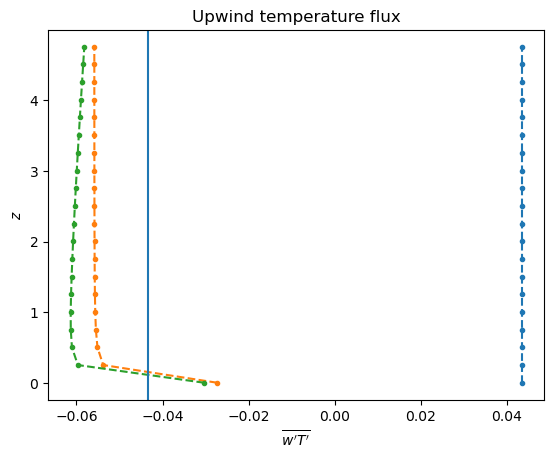

In [6]:
plt.plot(FluxT[0, :20], z[:20], '.--')
plt.plot(FluxT[-1, :20], z[:20], '.--')
plt.plot(FluxT[100, :20], z[:20], '.--')
plt.xlabel("$\overline{w'T'}$")
plt.ylabel("$z$")
plt.title("Upwind temperature flux")
# plt.xlim(0, 0.1)
plt.axvline(wT_down)

Text(0.5, 1.0, 'Upwind temperature flux')

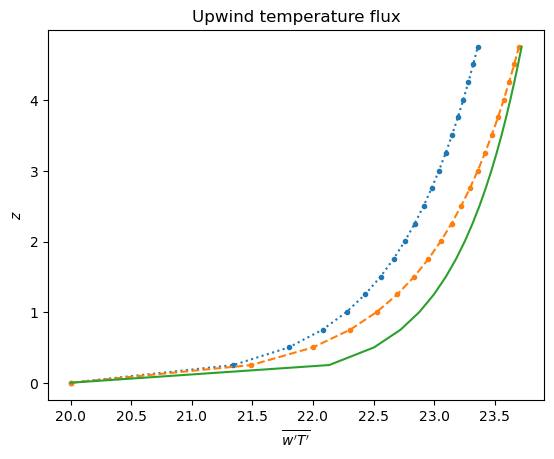

In [7]:
# plt.plot(T[0, :20], z[:20], '.--')
plt.plot(T[-1, :20], z[:20], '.:')
plt.plot(T[100, :20], z[:20], '.--')
plt.plot(Tdown[:20], z[:20], '-')
plt.xlabel("$\overline{w'T'}$")
plt.ylabel("$z$")
plt.title("Upwind temperature flux")
# plt.xlim(0, 0.1)


Text(0.5, 1.0, 'Upwind temperature flux')

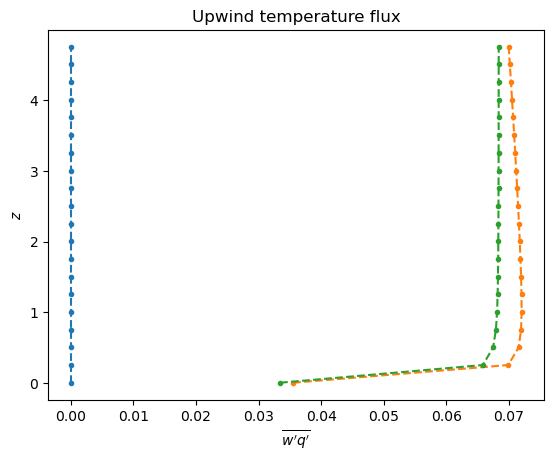

In [8]:
plt.plot(FluxQ[0, :20], z[:20], '.--')
plt.plot(FluxQ[100, :20], z[:20], '.--')
plt.plot(FluxQ[-1, :20], z[:20], '.--')
plt.xlabel("$\overline{w'q'}$")
plt.ylabel("$z$")
plt.title("Upwind temperature flux")
# plt.xlim(0, 0.1)





11.857149944565718


Text(0, 0.5, ' $z$ (m)')

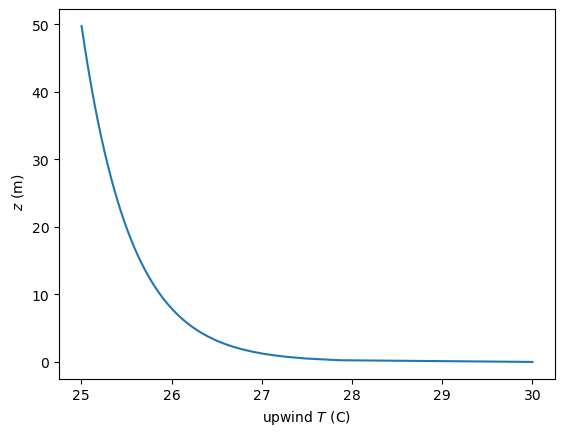

In [9]:
# Compute local Obukov length
Lo = - ustar**3/(k*g*FluxT[10, 0]/(273.15+Ts_d))
xi = z/Lo
print (Lo)

plt.plot(Tup, z)
plt.xlabel("upwind $T$ (C)")
plt.ylabel(" $z$ (m)")

Text(0.5, 1.0, 'Surface sensible and latent heat flux (W/m$^2$)')

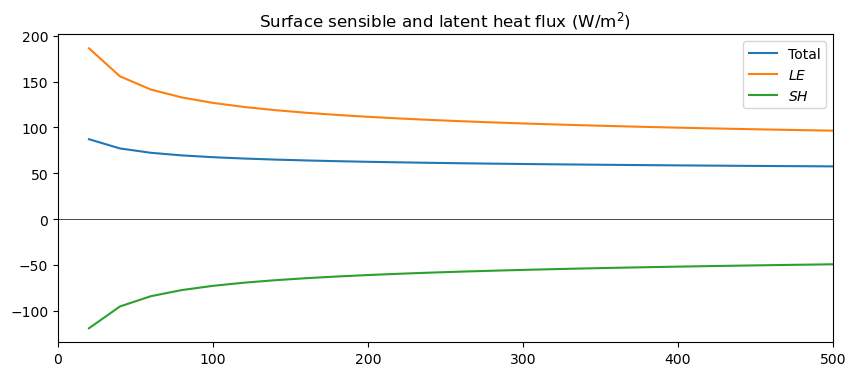

In [10]:
plt.figure(figsize = (10,4))
ax = plt.gca()
level = 0
FluxTotal = FluxT*1005*1.2 + FluxQ*2.5*1e6/1000
ax.plot(x[1:], FluxTotal[1:, level], label = 'Total')
ax.plot(x[1:], FluxQ[1:, level]*2.260*1e6/1000, label = "$LE$")
ax.plot(x[1:], FluxT[1:, level]*1005*1.2, label = "$SH$")
# ax.axhline(FluxT[-1, level], c = 'C2')
ax.legend()
ax.axhline(0, lw = .5, c= 'k')
ax.set_xlim(0, 500)
ax.set_title("Surface sensible and latent heat flux (W/m$^2$)")

In [11]:
xx, TT = padit(x, nz, Tup, T)
xx, QQ = padit(x, nz, Qup, Q)

xx, FluxQQ = padit(x, nz, FluxQ[0, :], FluxQ)
xx, FluxTT = padit(x, nz, FluxT[0, :], FluxT)


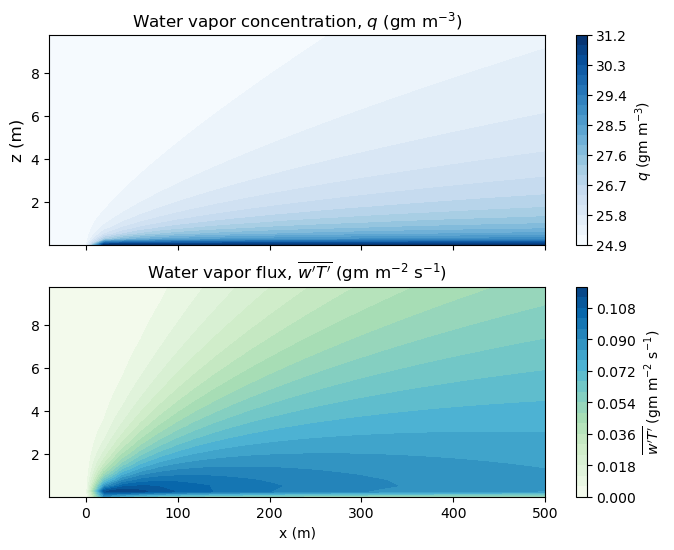

In [12]:
fig, axes = plt.subplots(2, 1, figsize = (8, 6), sharex = True)

xind = np.where(xx > 500)[0][0]
zind = np.where(z > 10)[0][0]
fontsize = 12

ax = axes[0]
g = axes[0].contourf(xx[:xind], z[:zind], QQ[:xind, :zind].T, 20, vmin = Ta_u, cmap = "Blues")
ax.set_ylabel("z (m)", fontsize = fontsize)
plt.colorbar(g, label="$q$ (gm m$^{-3}$)")
ax.set_title("Water vapor concentration, $q$ (gm m$^{-3}$)", fontsize=fontsize)

ax = axes[1]
g = axes[1].contourf(xx[:xind], z[:zind], FluxQQ[:xind, :zind].T, 20,  cmap = "GnBu")
ax.set_xlabel("x (m)")

ax.set_title("Water vapor flux, $\overline{w'T'}$ (gm m$^{-2}$ s$^{-1}$)", fontsize=fontsize)

plt.colorbar(g, label="$\overline{w'T'}$ (gm m$^{-2}$ s$^{-1}$)")

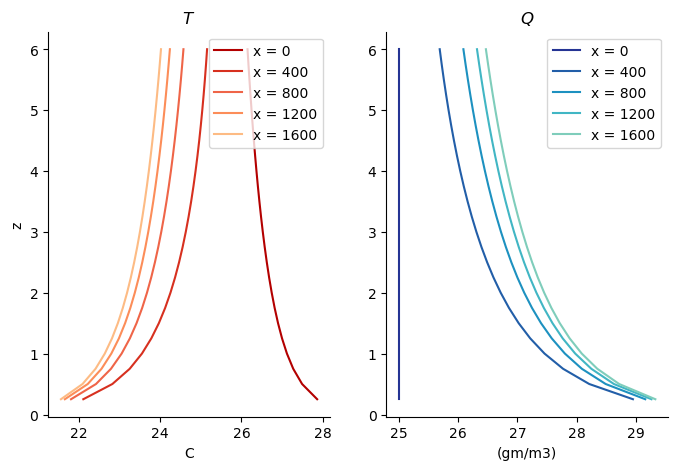

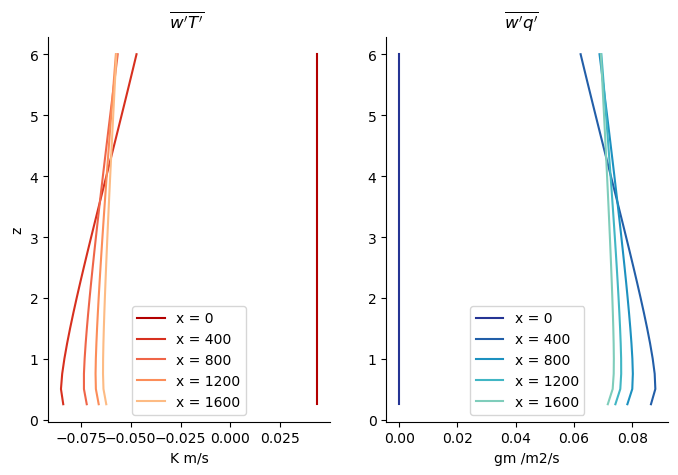

In [25]:
reds = ['#fff7ec','#fee8c8','#fdd49e','#fdbb84','#fc8d59','#ef6548','#d7301f','#b30000','#7f0000']
blues = ['#ffffd9','#edf8b1','#c7e9b4','#7fcdbb','#41b6c4','#1d91c0','#225ea8','#253494','#081d58']

zind = 25
xinds = np.arange(0, 100, 20)

fig, axes = plt.subplots(1,2, figsize = (8, 5))
ax = axes[0]
for ind, i in enumerate(xinds):
    ax.plot( T[i, 1:zind], z[1:zind], label = "x = {0:.0f}".format(x[i]), c = reds[-ind-2])
ax.legend()
ax.set_xlabel("C")
ax.set_ylabel("z")
ax.set_title("$T$")

ax = axes[1]
for ind, i in enumerate(xinds):
    ax.plot( Q[i, 1:zind], z[1:zind], label = "x = {0:.0f}".format(x[i]), c = blues[-ind-2])
   
ax.legend()
ax.set_xlabel("(gm/m3)")
ax.set_title("$Q$ ")
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig, axes = plt.subplots(1,2, figsize = (8, 5))
ax = axes[0]
for ind, i in enumerate(xinds):
    ax.plot( FluxT[i][1:zind], z[1:zind], label = "x = {0:.0f}".format(x[i]), c = reds[-ind-2])
ax.legend()
ax.set_xlabel("K m/s")
ax.set_ylabel("z")
ax.set_title("$\overline{w'T'} \ $ ")

ax = axes[1]
for ind, i in enumerate(xinds):
    ax.plot( FluxQ[i][1:zind], z[1:zind], label = "x = {0:.0f}".format(x[i]), c = blues[-ind-2])

ax.legend()
ax.set_xlabel("gm /m2/s")
ax.set_title("$\overline{w'q'} \ $  ")
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

Text(0.5, 1.0, "$\\overline{w'q'}$")

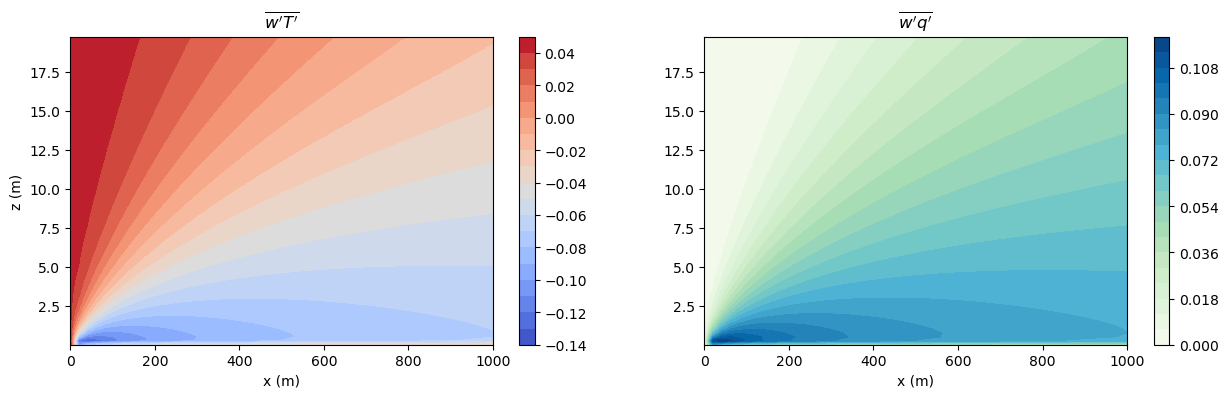

In [26]:
fig, axes = plt.subplots(1,2, figsize = (15, 4))

xind = np.where(x > 1000)[0][0]
zind = np.where(z > 20)[0][0]

ax = axes[0]
g = axes[0].contourf(x[:xind], z[:zind], FluxT[:xind, :zind].T, 20,cmap = "coolwarm")
ax.set_xlabel("x (m)")
ax.set_ylabel("z (m)")
plt.colorbar(g)

ax.set_title("$\overline{w'T'}$")

ax = axes[1]
g = axes[1].contourf(x[:xind], z[:zind], FluxQ[:xind, :zind].T, 20,  cmap = "GnBu")
ax.set_xlabel("x (m)")
plt.colorbar(g)
ax.set_title("$\overline{w'q'}$")


Text(0.5, 1.0, 'z < 20 m')

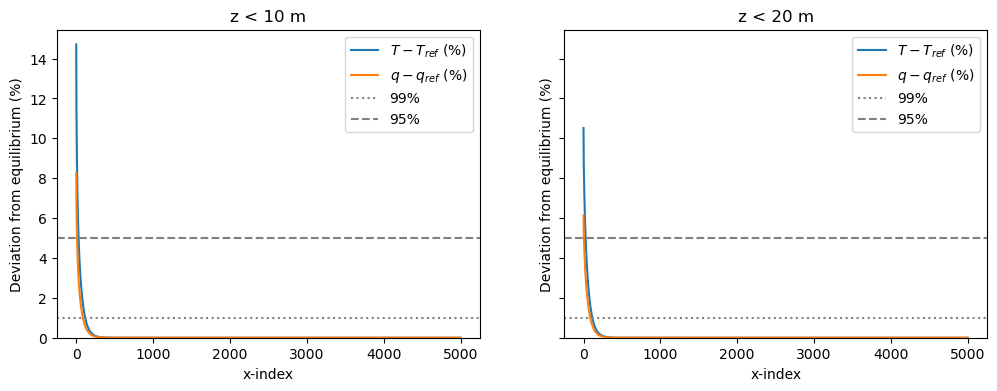

In [29]:
# Estimate fetch length: how far downwind before T and q have equilibrated.
#
# Method: for each x-station, take the vertical mean (over z < threshold) of
# the *percent deviation* from the far-field reference column (T[-1], Q[-1]).
#
#   T deviation  = mean_z[ (T(x,z) - T_ref(z)) / T_ref(z) ] × 100  %
#   q deviation  = mean_z[ (Q_ref(z) - Q(x,z)) / Q_ref(z)  ] × 100  %
#         (note sign flip for q: q decreases toward the new surface value)
#
# The two panels repeat the calculation for different height limits (10 m, 20 m)
# to check sensitivity to the column depth chosen.

fig, axes = plt.subplots(1,2, sharey = True, figsize = (12, 4))
ax = axes[0]

# --- Left panel: z < 10 m ---
ind = np.where(z> 10)[0][0]
ref = T[-1][:ind]    # far-field reference temperature profile
ax.plot(( ((T[:, :ind] - ref)/ref).T).mean(0)*100, label = "$T - T_{ref}$ (%)")
ref = Q[-1][:ind]    # far-field reference moisture profile
ax.plot(  ( ( (- Q[:, :ind] + ref)/ref).T).mean(0)*100, label = "$q - q_{ref}$ (%)")
ax.axhline(1, ls = ":", c = 'grey', label = "99%")   # 1% = 99% equilibrated
ax.axhline(5, ls = "--", c = 'grey', label = "95%")  # 5% = 95% equilibrated
ax.set_ylim(0) 
ax.legend()
ax.set_ylabel("Deviation from equilibrium (%)")
ax.set_xlabel("x-index")
ax.set_title("z < 10 m" )

# --- Right panel: z < 20 m ---
ax = axes[1]
ind = np.where(z> 20)[0][0]
ref = T[-1][:ind]
ax.plot(( ((T[:, :ind] - ref)/ref).T).mean(0)*100, label = "$T - T_{ref}$ (%)")
ref = Q[-1][:ind]
ax.plot(  ( ( (- Q[:, :ind] + ref)/ref).T).mean(0)*100, label = "$q - q_{ref}$ (%)")
ax.axhline(1, ls = ":", c = 'grey', label = "99%")
ax.axhline(5, ls = "--", c = 'grey', label = "95%")
ax.set_ylim(0)
ax.legend()
ax.set_ylabel("Deviation from equilibrium (%)")
ax.set_xlabel("x-index")
ax.set_title("z < 20 m" )

Text(0.5, 1.0, 'z < 20 m')

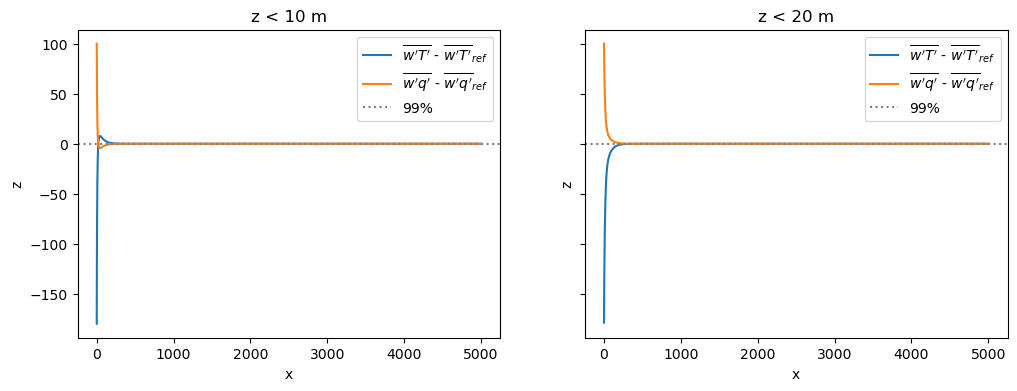

In [28]:

fig, axes = plt.subplots(1,2, sharey = True, figsize = (12, 4))
ax = axes[0]

ind = np.where(z> 10)[0][0]
ref = FluxT[-1][:ind]
ax.plot(( ((FluxT[:, :ind] - ref)/ref).T).mean(0)*100, label = "$\overline{w'T'}$ - $\overline{w'T'}_{ref}$ ")
ref = FluxQ[-1][:ind]
ax.plot(  ( ( (- FluxQ[:, :ind] + ref)/ref).T).mean(0)*100, label = "$\overline{w'q'}$ - $\overline{w'q'}_{ref}$ ")
ax.axhline(0, ls = ":", c = 'grey', label = "99%")
# ax.set_ylim(0) 
ax.legend()
ax.set_ylabel("z")
ax.set_xlabel("x")
ax.set_title("z < 10 m" )

ax = axes[1]
ind = np.where(z> 20)[0][0]
ref = FluxT[-1][:ind]
ax.plot(( ((FluxT[:, :ind] - ref)/ref).T).mean(0)*100, label = "$\overline{w'T'}$ - $\overline{w'T'}_{ref}$ ")
ref = FluxQ[-1][:ind]
ax.plot(  ( ( (- FluxQ[:, :ind] + ref)/ref).T).mean(0)*100, label = "$\overline{w'q'}$ - $\overline{w'q'}_{ref}$ ")
ax.axhline(0, ls = ":", c = 'grey', label = "99%")
# ax.set_ylim(0)
ax.legend()
ax.set_ylabel("z")
ax.set_xlabel("x")
ax.set_title("z < 20 m" )


## Comparison to Sutton's Analytical Solution

Sutton (1934) derived a classical solution for scalar transport downwind of an abrupt surface-condition change under neutral stability with a power-law wind profile $U \propto z^m$.

**Boundary layer depth**

Sutton showed that the depth of the advective internal boundary layer grows as a power law in fetch:

$$
\delta(x) \sim x^{\,\frac{m}{1+2m}}
$$

For $m = 1/7$ (the standard neutral log-law approximation at small $z$), this gives $\delta \sim x^{0.7}$.  
The vertically integrated excess scalar $\int [Q(x,z)-Q_a]\,dz$ should therefore also scale as $x^{0.7}$.

**Surface flux (fetch-mean)**

Brutsaert (1982, Eq. 7.54) extended Sutton's result to give the fetch-mean surface evaporation over a strip of length $x_f$:

$$
\bar{E}(x_f) = C_p \, u_* \, (Q_s - Q_a) \, x_f^{-\nu}, \qquad \nu = \frac{m}{1+2m}
$$

where $C_p$ is a dimensionless coefficient that depends on the roughness length and the velocity-profile exponent $m$.

**What the comparison tests**

1. The vertical integral of excess moisture vs $x^{0.7}$ (Sutton power law).
2. The surface flux `FluxQ[:,0]` vs the Brutsaert fetch-mean prediction $\bar{E}(x)$ and its local-flux equivalent $(1-\nu)\bar{E}(x)$.

Agreement validates the numerical scheme and gives confidence in using the model for more complex scenarios (varying surface conditions, stability effects) where the analytical solution no longer applies.

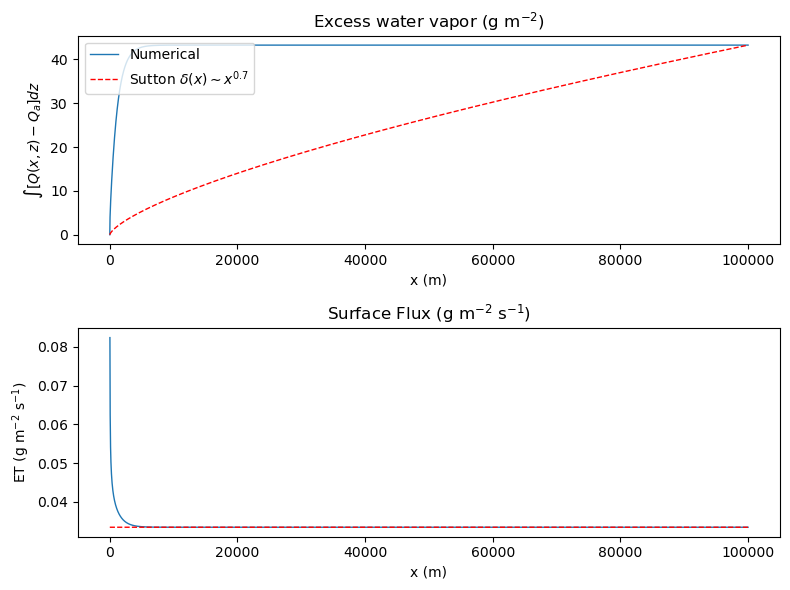

In [17]:

# Plot excess water vapor and surface flux
plt.subplots(1, 2, figsize = (8,6))
plt.clf()
QQ = np.sum(Q - Qa, axis=1) * dz

plt.subplot(2, 1, 1)
plt.plot(x, QQ, '-', linewidth=1)
plt.plot(x, np.max(QQ) * (x / Lx) ** 0.7, 'r--', linewidth=1)
plt.xlabel('x (m)')
plt.ylabel(r'$\int [Q(x,z) - Q_a]dz$')
plt.title('Excess water vapor (g m$^{-2}$)')
plt.legend(['Numerical', 'Sutton $\delta(x) \sim x^{0.7}$'], loc='upper left')

plt.subplot(2, 1, 2)
plt.plot(x[1:], FluxQ[1:, 0], '-', linewidth=1)
# plt.plot(x[1:], k*ustar*(Q[1:, 0] - Q[1:,10])/(np.log(z[10]/z[0])),  '-', linewidth=1)

plt.plot(x, np.ones(nx + 1) * FluxQ[nx, 0], 'r--', linewidth=1)
plt.xlabel('x (m)')
plt.ylabel('ET (g m$^{-2}$ s$^{-1}$)')
plt.title('Surface Flux (g m$^{-2}$ s$^{-1}$)')
plt.tight_layout()


Text(0.5, 1.0, '$(q-q_a)/(q_s-q_a)$')

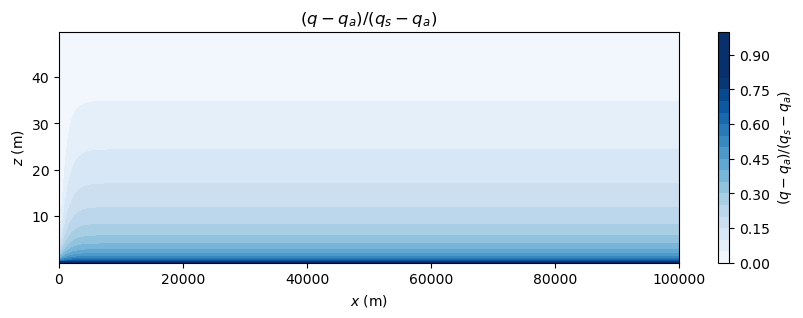

In [18]:
# Normalized concentration
Qd = (Q - Qa) / (Qs - Qa)

plt.figure(3, figsize = (10,3))
plt.clf()
plt.contourf(x, z, Qd.T.round(5), 20, vmax = 0.8, cmap='Blues')
plt.xlabel(r'$\it{x}$ (m)', fontweight='normal', fontsize=10)
plt.ylabel(r'$\it{z}$ (m)', fontweight='normal', fontsize=10)
plt.colorbar(label=r'$(q-q_a)/(q_s-q_a)$')
plt.title('$(q-q_a)/(q_s-q_a)$')


In [19]:
m = 1/7
v = m / (1 + 2*m)

import numpy as np
from math import gamma

def Ebar_754_notebookBC_Q(
    xf_m,
    ustar_mps,
    z0_m,            # use zoh from notebook 
    Qs_gm3,
    Qa_gm3,
    m=1/7,
    Cp=5.5,):
    """
    Fetch-mean flux \bar{E}(x_f) from Brutsaert Eq (7.54), using vapor concentration Q.
    BCs matched to notebook dry->wet step:
      Q(0,z)=Qa, Q(x,zmax)=Qa, Q(x,z0)=Qs for x>0 -> Ea=0 and q_as=q_a.

    Returns:
      Ebar in kg/m^2/s (== mm/s of water equivalent)
    """
    v = m / (1 + 2*m)

    # Eq (7.55) in SI units (same algebra; just use meters and m/s)
    a = Cp * ustar_mps / (z0_m ** m)
    b = ustar_mps * (z0_m ** m) / (Cp * m)

    pref = (1 - v)**(2*v - 2) * (m + 1)**(1 - 2*v) / gamma(v)

    # convert ΔQ from g/m^3 to kg/m^3
    dQ = (Qs_gm3 - Qa_gm3) / 1000.0

    # \bar{E} = a^v b^(1-v) x_f^{-v} * pref * ΔQ
    return (a**v) * (b**(1 - v)) * (xf_m**(-v)) * pref * dQ


def to_mmday(flux_kg_m2_s):
    return flux_kg_m2_s * 86400.0

# notebook: FluxQ is in g/m^2/s (since Q is g/m^3 and z is m)
E_local_g_m2_s = FluxQ[1:, 0]
x_m = x[1:]
dx = x[1] - x[0]

Ebar_num_g_m2_s = np.cumsum(E_local_g_m2_s) * dx / x_m
Ebar_num_mmday = Ebar_num_g_m2_s * 86400.0 / 1000.0  # == *86.4

Ebar_an_mmday = to_mmday(Ebar_754_notebookBC_Q(
    x_m, ustar_mps=ustar, z0_m=zoh, Qs_gm3=Qs, Qa_gm3=Qa, Cp = 6.5, m=1/7))

E_local_num_mmday = FluxQ[1:, 0] * 86.4

# Analytic local flux corresponding to Eq. (7.54):
# if  \bar{E}(x) = A x^{-v}  then  E(x) = (1-v) \bar{E}(x)
E_local_an_mmday = (1 - v) * Ebar_an_mmday
# can't be more complicated than if treating patches independently as if not cross talk

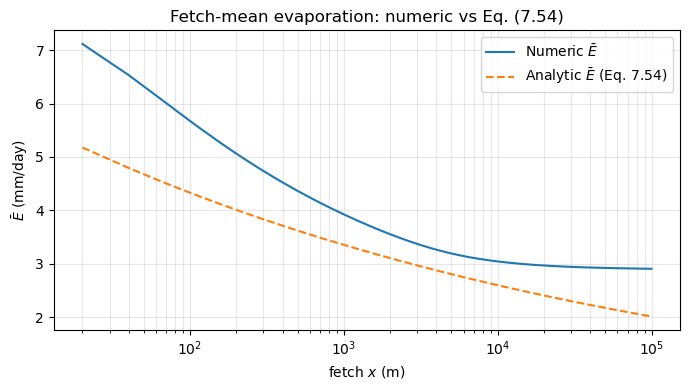

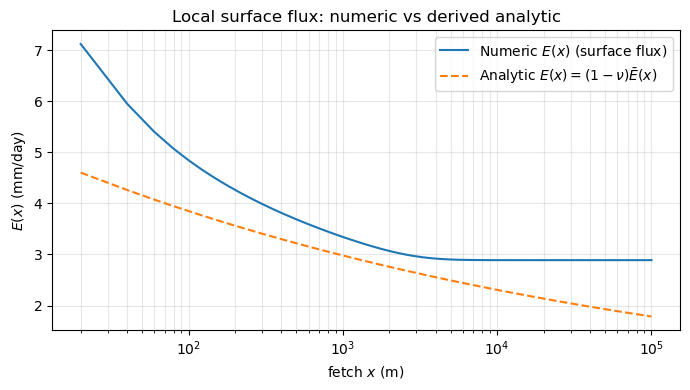

In [20]:
# -----------------------------
# Plot 1: fetch-mean (Eq. 7.54)
# -----------------------------
plt.figure(figsize=(7, 4))
plt.plot(x_m, Ebar_num_mmday, label=r"Numeric $\bar{E}$")
plt.plot(x_m, Ebar_an_mmday, "--", label=r"Analytic $\bar{E}$ (Eq. 7.54)")
plt.xscale("log")
plt.xlabel(r"fetch $x$ (m)")
plt.ylabel(r"$\bar{E}$ (mm/day)")
plt.title(r"Fetch-mean evaporation: numeric vs Eq. (7.54)")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# Plot 2: local surface flux
# -----------------------------
plt.figure(figsize=(7, 4))
plt.plot(x_m, E_local_num_mmday, label=r"Numeric $E(x)$ (surface flux)")
plt.plot(x_m, E_local_an_mmday, "--", label=r"Analytic $E(x)=(1-\nu)\bar{E}(x)$")
plt.xscale("log")
plt.xlabel(r"fetch $x$ (m)")
plt.ylabel(r"$E(x)$ (mm/day)")
plt.title(r"Local surface flux: numeric vs derived analytic")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


Best fit: u* = 0.2582 m/s, Cp = 6.17, log-RMSE = 0.01135


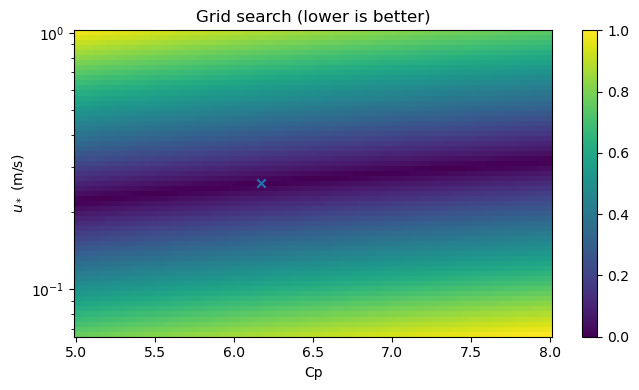

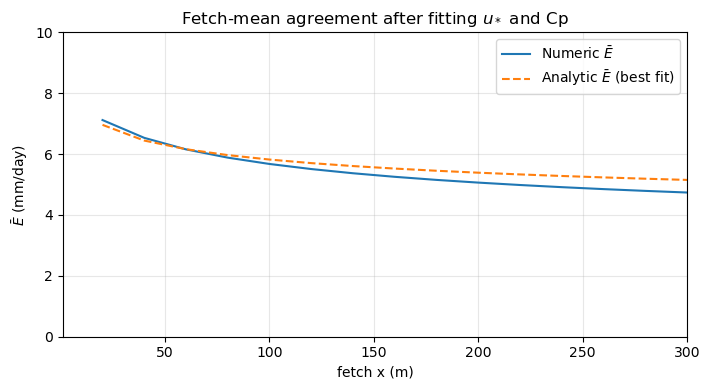

In [21]:

import numpy as np
import matplotlib.pyplot as plt

# ---- inputs assumed to already exist ----
# x_m              # 1D array (m)
# Ebar_num_mmday   # 1D array (mm/day), running-mean of numeric surface flux
# zoh              # scalar roughness length (m) used in the notebook BC (or pick one)
# Qs, Qa           # g/m^3
# m                # exponent (e.g., 1/7)

# -------------------------
# 1) choose fit window
# -------------------------
mask = np.isfinite(x_m) & np.isfinite(Ebar_num_mmday) & (x_m > 0) & (Ebar_num_mmday > 0)

# optional: ignore first few grid cells near x=0 (often most sensitive numerically)
x_min = 20
x_max = 100
mask &= (x_m < x_max)
mask &= (x_m > x_min)

x_fit = x_m[mask]
y_fit = Ebar_num_mmday[mask]

# -------------------------
# 2) grids to search
# -------------------------
# center the u* grid around current ustar guess if it exists
ustar_guess = float(ustar) if "ustar" in globals() else 0.20  # m/s fallback

ustar_grid = np.logspace(np.log10(ustar_guess/3), np.log10(ustar_guess*5), 61)  # m/s
Cp_grid    = np.linspace(5.0, 8.0, 101)

# -------------------------
# 3) objective: minimize log-RMSE
# -------------------------
eps = 1e-12  # protects log() if any tiny values slip in

scores = np.full((ustar_grid.size, Cp_grid.size), np.nan)

for i, ustar_try in enumerate(ustar_grid):
    for j, Cp_try in enumerate(Cp_grid):
        y_an = to_mmday(Ebar_754_notebookBC_Q(
            x_fit,
            ustar_mps=ustar_try,
            z0_m=zoh,
            Qs_gm3=Qs,
            Qa_gm3=Qa,
            m=m,
            Cp=Cp_try,
        ))

        # log-RMSE (relative-fit style)
        # why is this our objective function? 
        le = np.log(y_an + eps) - np.log(y_fit + eps)
        scores[i, j] = np.sqrt(np.mean(le**2))

# best params
ibest, jbest = np.unravel_index(np.nanargmin(scores), scores.shape)
ustar_best = ustar_grid[ibest]
Cp_best    = Cp_grid[jbest]
best_score = scores[ibest, jbest]

print(f"Best fit: u* = {ustar_best:.4g} m/s, Cp = {Cp_best:.4g}, log-RMSE = {best_score:.4g}")

# -------------------------
# 4) recompute best-fit analytic curve over full x_m
# -------------------------
Ebar_an_best_mmday = to_mmday(Ebar_754_notebookBC_Q(
    x_m, ustar_mps=ustar_best, z0_m=zoh, Qs_gm3=Qs, Qa_gm3=Qa, m=m, Cp=Cp_best
))

# -------------------------
# 5) plots: heatmap + overlay
# -------------------------
# Heatmap of score
CpM, uM = np.meshgrid(Cp_grid, ustar_grid)
plt.figure(figsize=(7, 4))
plt.pcolormesh(CpM, uM, scores, shading="auto")
plt.yscale("log")
plt.xlabel("Cp")
plt.ylabel(r"$u_*$ (m/s)")
plt.title("Grid search (lower is better)")
plt.scatter([Cp_best], [ustar_best], marker="x")
plt.tight_layout()
plt.colorbar()
plt.show()

# Overlay of best-fit analytic vs numeric fetch-mean
plt.figure(figsize=(7, 4))
plt.plot(x_m, Ebar_num_mmday, label=r"Numeric $\bar{E}$")
plt.plot(x_m, Ebar_an_best_mmday, "--", label=r"Analytic $\bar{E}$ (best fit)")
# plt.xscale("log")
plt.xlabel("fetch x (m)")
plt.ylabel(r"$\bar{E}$ (mm/day)")
plt.title("Fetch-mean agreement after fitting $u_*$ and Cp")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.xlim(1, 300)
plt.ylim(0, 10)
plt.show()


Why can't we use analytical solution directly? 
Requires upwind ET, Qs, Qa... 

Well we could, but numerically, we can handle more complex boundary conditions. 
i.e., don't need to assume upwind boundary conditions in equilibrium, we can change surface conditions before internal boundary layer has fully adjusted back to equilibrium. 


**Fetch-mean vs. local surface flux**

Brutsaert’s Eq. 7.54 predicts the fetch-mean evaporation over a strip of fetch $x_f$,

$$
\bar{E}(x_f)
= \frac{1}{x_f}\int_{0}^{x_f} E(x)\,dx
$$
where $E(x)$ is the local surface evaporation rate at downwind distance $x$.


`FluxQ[:,0]` corresponds (up to unit conversion) to the local flux $E(x)$, not the mean $\bar{E}(x_f)$.

**Compare mean-to-mean**

Given discrete samples $E_i \approx E(x_i)$ on a uniform grid with spacing $\Delta x$,
a running estimate of the fetch-mean is
$$
\bar{E}_{\text{num}}(x_i)
\;\approx\;
\frac{1}{x_i}\sum_{k=1}^{i} E_k\,\Delta x,
\qquad i=1,2,\dots
$$

which can be compared  to the analytical $\bar{E}_{\text{an}}(x)$ from Eq. 7.54.

**Compare local-to-local**

The analytical prediction has the power-law form:
$$
\bar{E}_{\text{an}}(x) = A\,x^{-\nu},
$$

The corresponding local flux is computed as:
$$
E_{\text{an}}(x)
= \frac{d}{dx}\!\left[x\,\bar{E}_{\text{an}}(x)\right]
= \frac{d}{dx}\!\left[A\,x^{1-\nu}\right]
= (1-\nu)\,A\,x^{-\nu}
= (1-\nu)\,\bar{E}_{\text{an}}(x).
$$
So we can compare `FluxQ[:,0]` (local) against $(1-\nu)\bar{E}_{\text{an}}(x)$.
